<a href="https://colab.research.google.com/github/Vitalyastiy/courses/blob/main/analytics_HT_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы аналитики. Домашнее задание

В этом домашнем задании вы отработаете навыки, полученные в модуле, на реальных данных о населении в разных странах мира по годам.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [185]:
df = pd.read_csv("https://raw.githubusercontent.com/aiedu-courses/all_datasets/main/Population.csv", delimiter=';')

In [3]:
df.head()

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,54608.0,55811.0,56682.0,57475.0,58178.0,58782.0,59291.0,59522.0,59471.0,...,102880.0,103594.0,104257.0,104874.0,105439.0,105962.0,106442.0,106585.0,106537.0,106445.0
1,Africa Eastern and Southern,130692579.0,134169237.0,137835590.0,141630546.0,145605995.0,149742351.0,153955516.0,158313235.0,162875171.0,...,567892149.0,583651101.0,600008424.0,616377605.0,632746570.0,649757148.0,667242986.0,685112979.0,702977106.0,720859132.0
2,Afghanistan,8622466.0,8790140.0,8969047.0,9157465.0,9355514.0,9565147.0,9783147.0,10010030.0,10247780.0,...,31541209.0,32716210.0,33753499.0,34636207.0,35643418.0,36686784.0,37769499.0,38972230.0,40099462.0,41128771.0
3,Africa Western and Central,97256290.0,99314028.0,101445032.0,103667517.0,105959979.0,108336203.0,110798486.0,113319950.0,115921723.0,...,387204553.0,397855507.0,408690375.0,419778384.0,431138704.0,442646825.0,454306063.0,466189102.0,478185907.0,490330870.0
4,Angola,5357195.0,5441333.0,5521400.0,5599827.0,5673199.0,5736582.0,5787044.0,5827503.0,5868203.0,...,26147002.0,27128337.0,28127721.0,29154746.0,30208628.0,31273533.0,32353588.0,33428486.0,34503774.0,35588987.0


В следующих ячейках мы создаем объекты:

* `years` - список годов в данных

* `aruba_population` - население на Арубе по годам

In [4]:
years = df.columns[1:].astype(int)

years[-5:]

Index([2018, 2019, 2020, 2021, 2022], dtype='int64')

In [6]:
aruba_population = df[df['Country Name'] == 'Aruba'].values[0][1:]

aruba_population[:5]

array([54608.0, 55811.0, 56682.0, 57475.0, 58178.0], dtype=object)

Построим график численности населения на Арубе по годам.

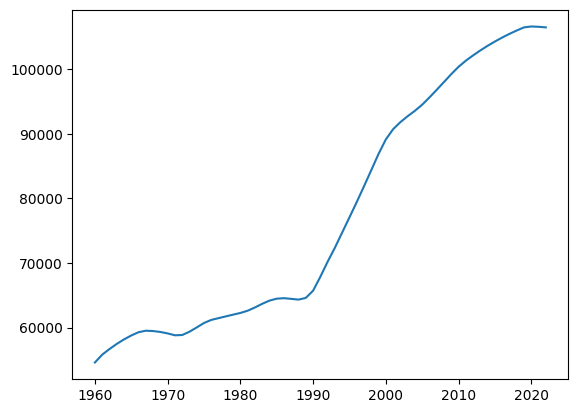

In [7]:
plt.plot(years, aruba_population, '-')

## Задание 1

По аналогии с кодом выше нарисуйте график населения Болгарии.

Можно ли сказать, что население постоянно растет?

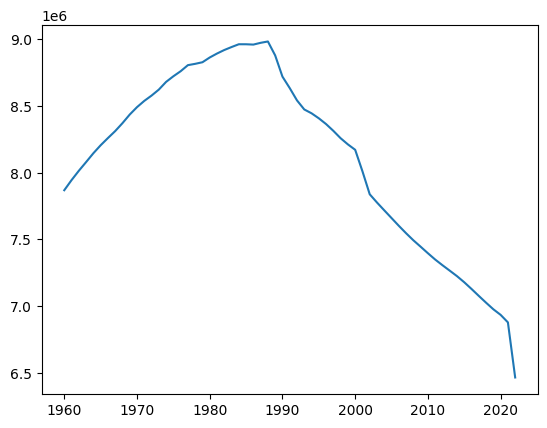

In [49]:
# ваш код здесь
years = df.columns[1:].astype(int)
bulgaria_population = df[df['Country Name'] == 'Bulgaria'].values[0][1:]
plt.plot( years, bulgaria_population, '-')

## Задание 2

Вычислите среднее значение населения Болгарии за все годы, представленные в таблице. Ответ округлите до целого числа.

In [51]:
# ваш код здесь
bulgaria_population.mean()

np.float64(8120173.349206349)

## Задание 3

Вычислите среднее значение населения Болгарии за пять последних лет, представленных в таблице. Верно ли, что в среднем за пять последних лет наблюдается прирост населения по сравнению со средним значением за все годы?

In [82]:
# ваш код здесь

df[df['Country Name'] == 'Bulgaria'].iloc[:, -5:].mean(axis = 1)

,0
21,6855530.6


## Задание 4

Вычислите медиану населения Болгарии за все годы из таблицы. Ответ округлите до целого числа.

In [87]:
# ваш код здесь
df[df['Country Name'] == 'Bulgaria'].iloc[:, 1:].median(axis = 1)

,0
21,8258057.0


## Задание 5

Найдите страну, население которой ведет себя похожим образом (как в Болгарии) - сначала растет, а потом падает. Что это за страна (из перечисленных)?

* Доминиканская республика
* Хорватия
* Эритрея
* Германия
* Косово

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

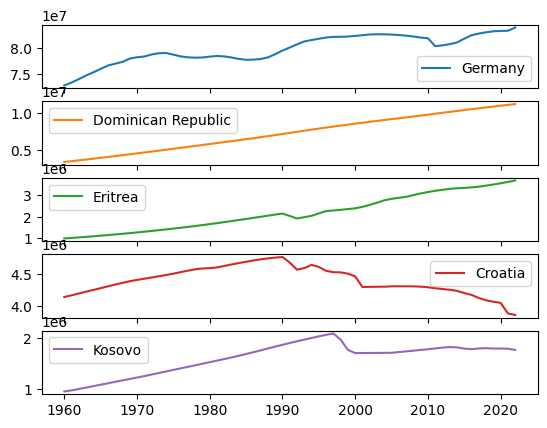

In [116]:
# ваш код здесь
list(df['Country Name']) #
df_filtered = df[df['Country Name'].isin(['Dominican Republic', 'Croatia', 'Eritrea', 'Germany', 'Kosovo' ])]
df_plot = df_filtered.set_index('Country Name')
df_plot.T.plot(subplots=True)


## Задание 6

В каком году в найденной в предыдущем задании стране был пик населения?

In [140]:
# ваш код здесь

df_filtered = df[df['Country Name'].isin([ 'Croatia'])]
df_filtered = df_filtered.set_index('Country Name')
df_filtered.sort_values(by='Croatia', axis=1, ascending=False).iloc[:, :1]

,1990
Country Name,
Croatia,4777368.0


## Задание 7

Вычислите корреляцию Пирсона между населением Болгарии и страны, найденной в задании 5. Ответ округлите до сотых.

In [162]:
# ваш код здесь
x = df[df['Country Name'].isin(['Bulgaria'])].values[0][1:]
y = df[df['Country Name'].isin(['Croatia'])].values[0][1:]
print((pd.Series(x).corr(pd.Series(y))))


0.8943951015727729


## Задание 8

Вычислите несмещенное выборочное стандартное отклонение для населения страны, найденной в задании 5. Ответ округлите до целого числа.

In [179]:
# ваш код здесь
y = df[df['Country Name'].isin(['Croatia'])].values[0][1:]
print(np.std(y, ddof=1) , y.std(ddof=1))

218541.09620702732 218541.09620702732


## Задание 9

Вычислите несмещенное выборочное стандартное отклонение для населения Болгарии. Верно ли, что в Болгарии "разброс" относительно среднего количества населения больше, чем в стране, найденной в задании 5?

In [180]:
# ваш код здесь
x = df[df['Country Name'].isin(['Bulgaria'])].values[0][1:]
print(np.std(x, ddof=1) , x.std(ddof=1))

671811.517668296 671811.517668296


## Задание 10

Мы нашли две страны, в которых количество населения изменяется похожим образом. Попробуйте дать объяснение (исторические, социальные, экономические факторы) этому. Пишите ваш ответ в комментариях.

In [ ]:
# ваши мысли


## Задание 11 (бонус)

Есть ли в данных другие страны, население которых также похожим образом ведет себя на поведение численности населения в Болгарии? Среди этих стран есть ли та, корреляция населения которой с населением Болгарии больше найденной в задании 7?

Перечислите в комментариях найденные страны, а также укажите страну-лидер по корреляции с населением Болгарии.

In [191]:
# ваши эксперименты здесь
df1 = df.set_index('Country Name', drop=True).T
df1.corr()['Bulgaria'].sort_values(ascending=False)[:10]

,Bulgaria
Country Name,
Bulgaria,1.000000
Hungary,0.963528
Latvia,0.948011
Croatia,0.894395
Georgia,0.831630
Ukraine,0.796365
Lithuania,0.715208
Bosnia and Herzegovina,0.713830
Estonia,0.706073
